# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/124pritivarma6001-commits/flyrank_internship_ml/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research Ouestion
How can existing content with high search visibility but relatively low click-through rate (CTR) and good average search position be identified and prioritized for content fresh?

### Decision Supported
The analysis supports a practical content-review decision: which existing content should be reviewed first for a potential refresh.

The output is ranked action queue that prioritizes content opportunities using impressions, CTR, and average position. The ranking is intended to support human review rather than automatically change or publish content.

In [29]:
research_question = (
    "How can existing content with high search visibility but relatively low CTR "
    "and good average search position be identified and prioritized for content refresh?"
)

decision_supported = (
    "Prioritize content for human review using a ranked opportunity queue."
)

print("Research Question:")
print(research_question)

print("\nDecision Supported:")
print(decision_supported)

Research Question:
How can existing content with high search visibility but relatively low CTR and good average search position be identified and prioritized for content refresh?

Decision Supported:
Prioritize content for human review using a ranked opportunity queue.


## 2. Data

### Data Source

The analysis uses the public FlyRank internship warehouse dataset from Hugging Face.

The main source used for the opportunity-scoring analysis is the daily content performance data. Daily records were aggregated to the client-content level using total impressions, total clicks, and an impressions-weighted average search position.

### Final Analysis Dataset

After aggregation and validation, the final dataset contains **309,234 client-content rows**.

The main fields used in the analysis are:

- `client_hash_id` — pseudonymous client identifier
- `content_hash_id` — pseudonymous content identifier
- `impressions` — total search impressions
- `clicks` — total search clicks
- `ctr` — clicks divided by impressions
- `avg_position` — impressions-weighted average search position

Rows with missing impressions, clicks, or average position were excluded from the calculation. Rows with zero impressions were also excluded because CTR cannot be meaningfully calculated for them.

### Data Safety

The analysis uses hashed identifiers rather than client names or private URLs. No client names, private queries, or personally identifiable information are included in the analysis or final outputs.

In [30]:
# Section 2: Data summary

data_summary = {
    "source": "FlyRank internship warehouse (Hugging Face)",
    "source_table": "fact_content_daily_performance",
    "final_validated_rows": 309234,
    "main_features": [
        "impressions",
        "clicks",
        "ctr",
        "avg_position"
    ],
    "excluded_missing_metrics": True,
    "excluded_zero_impressions": True,
    "identifiers": "Pseudonymous client_hash_id and content_hash_id"
}

print("Data Source:")
print(data_summary["source"])

print("\nSource Table:")
print(data_summary["source_table"])

print("\nFinal Validated Rows:")
print(f"{data_summary['final_validated_rows']:,}")

print("\nMain Features:")
for feature in data_summary["main_features"]:
    print(f"- {feature}")

print("\nData Safety:")
print("- Missing metric rows excluded:", data_summary["excluded_missing_metrics"])
print("- Zero-impression rows excluded:", data_summary["excluded_zero_impressions"])
print("- Identifiers are pseudonymous.")

Data Source:
FlyRank internship warehouse (Hugging Face)

Source Table:
fact_content_daily_performance

Final Validated Rows:
309,234

Main Features:
- impressions
- clicks
- ctr
- avg_position

Data Safety:
- Missing metric rows excluded: True
- Zero-impression rows excluded: True
- Identifiers are pseudonymous.


## 3. Methodology

### Baseline Rule

A transparent rule-based baseline was created to identify content opportunities.

A content item is labelled as an **OPPORTUNITY** when all three conditions are satisfied:

- Impressions are at least **237**
- CTR is below **0.003026**
- Average position is at most **20**

The corresponding reason code is **LOW_CTR_GOOD_POSITION**, indicating that the content receives meaningful search visibility but has relatively weak CTR while maintaining a good search position.

### Machine Learning Model

A Decision Tree classifier was trained to reproduce the opportunity label using:

- `impressions`
- `ctr`
- `avg_position`

The model used a maximum depth of 4, balanced class weights, and a fixed random state of 42.

### Validation Strategy

The analysis first used an 80/20 content-level train-test split.

A stronger validation audit was then performed using a **client-grouped split**, ensuring that clients in the training set did not appear in the test set. This produced:

- **241,240 training rows**
- **67,994 test rows**
- **0 client overlap**

### Leakage and Claim Check

Because the opportunity label is defined directly from impressions, CTR, and average position, and these same variables are used as model features, the Decision Tree is primarily reproducing the existing rule.

Therefore, the resulting near-perfect metrics should **not** be interpreted as proof that the model can independently predict future CTR improvement. The result demonstrates successful reproduction of the transparent opportunity rule.

In [31]:
# Section 3: Methodology summary

baseline_rule = {
    "minimum_impressions": 237,
    "maximum_ctr": 0.003026,
    "maximum_avg_position": 20,
    "reason_code": "LOW_CTR_GOOD_POSITION"
}

model_settings = {
    "model": "Decision Tree",
    "max_depth": 4,
    "class_weight": "balanced",
    "random_state": 42
}

validation = {
    "train_rows": 241240,
    "test_rows": 67994,
    "client_overlap": 0
}

print("BASELINE RULE")
print(f"Impressions >= {baseline_rule['minimum_impressions']}")
print(f"CTR < {baseline_rule['maximum_ctr']}")
print(f"Average position <= {baseline_rule['maximum_avg_position']}")
print(f"Reason code: {baseline_rule['reason_code']}")

print("\nMODEL")
for key, value in model_settings.items():
    print(f"{key}: {value}")

print("\nCLIENT-GROUPED VALIDATION")
print(f"Training rows: {validation['train_rows']:,}")
print(f"Test rows: {validation['test_rows']:,}")
print(f"Client overlap: {validation['client_overlap']}")

BASELINE RULE
Impressions >= 237
CTR < 0.003026
Average position <= 20
Reason code: LOW_CTR_GOOD_POSITION

MODEL
model: Decision Tree
max_depth: 4
class_weight: balanced
random_state: 42

CLIENT-GROUPED VALIDATION
Training rows: 241,240
Test rows: 67,994
Client overlap: 0


## 4. Results (vs baseline)

### Model Performance

The Decision Tree reproduced the rule-defined opportunity label with perfect performance on the evaluated test split.

The client-grouped validation produced an Accuracy, Precision, Recall, and F1 score of **1.00** for all four metrics. This confirms that the model can reproduce the existing opportunity rule even when clients are separated between training and testing.

However, these results should be interpreted as **rule reproduction**, not as evidence of independent prediction of future CTR improvement, because the target definition is based on the same variables used as model features.

In [32]:
import pandas as pd

# Verified results from the Week 5 model and Week 6 client-grouped validation

results = pd.DataFrame({
    "Evaluation": [
        "Week 5 - Random 80/20",
        "Week 6 - Client Grouped"
    ],
    "Model": [
        "Decision Tree",
        "Decision Tree"
    ],
    "Accuracy": [
        1.00,
        1.00
    ],
    "Precision": [
        1.00,
        1.00
    ],
    "Recall": [
        1.00,
        1.00
    ],
    "F1": [
        1.00,
        1.00
    ]
})

results

,Evaluation,Model,Accuracy,Precision,Recall,F1
0,Week 5 - Random 80/20,Decision Tree,1.0,1.0,1.0,1.0
1,Week 6 - Client Grouped,Decision Tree,1.0,1.0,1.0,1.0


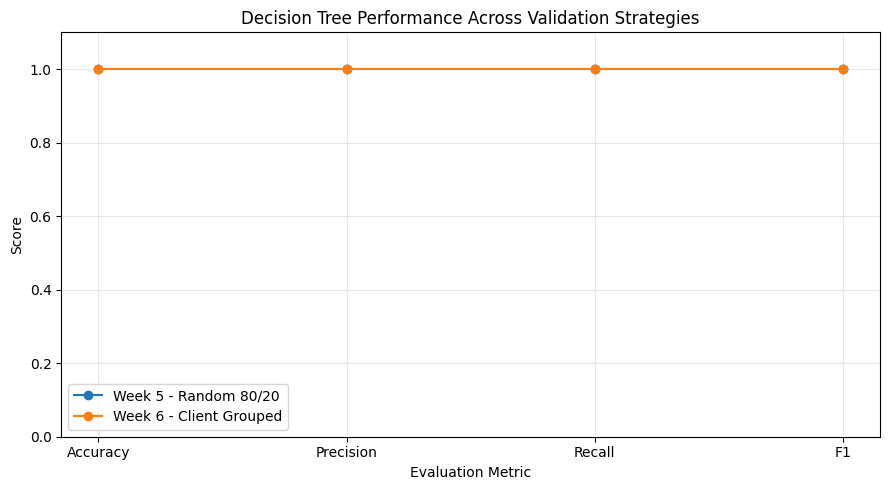

In [33]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1"]

week5_scores = [1.00, 1.00, 1.00, 1.00]
week6_scores = [1.00, 1.00, 1.00, 1.00]

x = range(len(metrics))

plt.figure(figsize=(9, 5))

plt.plot(x, week5_scores, marker="o", label="Week 5 - Random 80/20")
plt.plot(x, week6_scores, marker="o", label="Week 6 - Client Grouped")

plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.title("Decision Tree Performance Across Validation Strategies")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

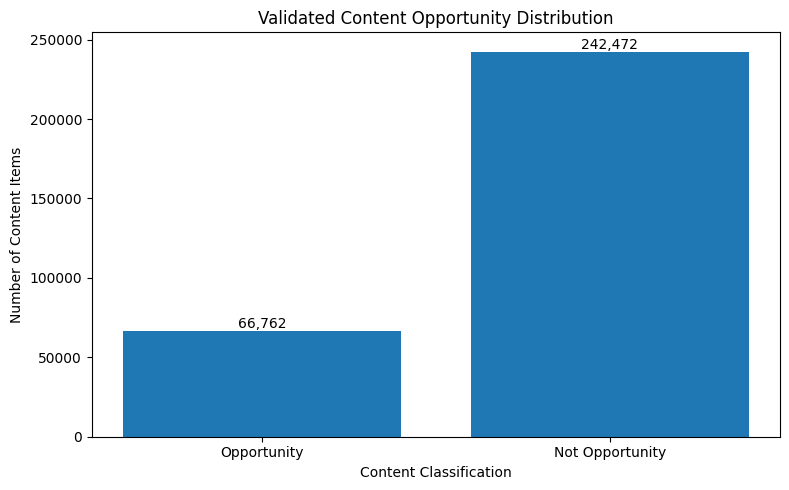

Total validated rows: 309,234
Opportunity rows: 66,762
Opportunity rate: 21.59%


In [34]:
import matplotlib.pyplot as plt

# Verified Week 7 results
total_rows = 309234
opportunity_rows = 66762
non_opportunity_rows = total_rows - opportunity_rows

labels = ["Opportunity", "Not Opportunity"]
values = [opportunity_rows, non_opportunity_rows]

plt.figure(figsize=(8, 5))

bars = plt.bar(labels, values)

plt.title("Validated Content Opportunity Distribution")
plt.xlabel("Content Classification")
plt.ylabel("Number of Content Items")

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

print(f"Total validated rows: {total_rows:,}")
print(f"Opportunity rows: {opportunity_rows:,}")
print(f"Opportunity rate: {opportunity_rows / total_rows:.2%}")

### Result Interpretation

The final validated dataset contains 309,234 client-content records, of which 66,762 (21.59%) are classified as opportunities by the rule-based scoring approach.

This indicates that the workflow identifies a focused subset of content for review rather than requiring the entire content set to be reviewed. The result is intended to help prioritize human attention toward content with high visibility, relatively low CTR, and good average search position.

## 5. Limitations

### Limitations and Honest Framing

This analysis has several limitations that should be considered when interpreting the results.

1. **Rule reproduction rather than independent prediction:**  
   The opportunity label is defined using impressions, CTR, and average position, and the same variables are used as model features. Therefore, the perfect model metrics mainly show that the Decision Tree reproduces the existing rule.

2. **No causal claim:**  
   The analysis does not establish that refreshing an identified content item will cause its CTR to increase.

3. **Historical data limitation:**  
   The workflow is based on observed historical search-performance data. Changes in search behaviour, content, or ranking conditions may affect future results.

4. **Human review is required:**  
   An opportunity score should be treated as a prioritization signal, not as an automatic decision to modify, publish, or delete content.

5. **Limited feature set:**  
   The model uses a small set of performance signals. Other factors such as search intent, content quality, seasonality, and competitive context are not directly modelled.

6. **No guarantee of business impact:**  
   Identifying an opportunity does not guarantee a measurable improvement in clicks, CTR, traffic, or other business outcomes.

In [35]:
# Section 5: Limitations and honest-claim checks

limitations = [
    "The model reproduces the rule-defined opportunity label rather than independently predicting future CTR improvement.",
    "The analysis does not establish that refreshing content will cause CTR to increase.",
    "The analysis is based on historical search-performance data.",
    "The opportunity output is a prioritization signal and requires human review.",
    "The model uses a limited set of performance features.",
    "Identifying an opportunity does not guarantee business impact."
]

print("LIMITATIONS AND HONEST CLAIMS\n")

for i, limitation in enumerate(limitations, start=1):
    print(f"{i}. {limitation}")

print("\nClaim framing:")
print("- Use: observed, measured, directional, decision-support")
print("- Avoid: guaranteed improvement, causal impact, or prediction of Google's algorithm")

LIMITATIONS AND HONEST CLAIMS

1. The model reproduces the rule-defined opportunity label rather than independently predicting future CTR improvement.
2. The analysis does not establish that refreshing content will cause CTR to increase.
3. The analysis is based on historical search-performance data.
4. The opportunity output is a prioritization signal and requires human review.
5. The model uses a limited set of performance features.
6. Identifying an opportunity does not guarantee business impact.

Claim framing:
- Use: observed, measured, directional, decision-support
- Avoid: guaranteed improvement, causal impact, or prediction of Google's algorithm


### Honest Framing

The results should be interpreted as decision-support evidence rather than a guarantee of future performance. In particular, the perfect classification metrics show that the Decision Tree reproduces the rule-defined opportunity label. They do not demonstrate that the model independently predicts which content will achieve higher CTR after a refresh.

The ranked output therefore supports human prioritization and review rather than automatic content changes.

## 6. Ranked recommendations

The recommended action is to prioritize content for **human review** using the opportunity signals identified in the analysis.

The ranking follows the Week 7 action-playbook logic:

1. Higher impressions are prioritized first because they represent greater search visibility.
2. Lower CTR is prioritized because it indicates relatively fewer clicks despite that visibility.
3. Better average position is prioritized because the content is already appearing in a useful search position.

The primary recommendation is therefore:

**Review high-impression, low-CTR content with good average position first for a potential content refresh.**

The action queue is a decision-support tool. It does not automatically publish, modify, or delete content.

In [36]:
# Section 6: Ranked recommendation summary

ranking_priority = [
    "1. Higher impressions",
    "2. Lower CTR",
    "3. Better average position"
]

recommended_action = "REVIEW_FOR_REFRESH"
reason_code = "HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION"

print("RANKED RECOMMENDATION\n")

for item in ranking_priority:
    print(item)

print("\nRecommended Action:")
print(recommended_action)

print("\nReason Code:")
print(reason_code)

print("\nAutomation Policy:")
print("- Human review required: True")
print("- Automatic publishing: False")
print("- Automatic deletion: False")

RANKED RECOMMENDATION

1. Higher impressions
2. Lower CTR
3. Better average position

Recommended Action:
REVIEW_FOR_REFRESH

Reason Code:
HIGH_IMPRESSIONS_LOW_CTR_GOOD_POSITION

Automation Policy:
- Human review required: True
- Automatic publishing: False
- Automatic deletion: False


## 7. Artifacts the paper embeds

The capstone analysis is supported by reproducible artifacts generated during the internship workflow.

Key artifacts include:

- **Week 7 action queue:** `work/outputs/week7_action_queue.csv`
- **Week 7 metrics:** `work/outputs/week7_metrics.json`
- **Opportunity distribution figure:** `work/figures/week7_opportunity_distribution.png`
- **Top-10 action queue figure:** `work/figures/week7_top10_action_queue.png`

These artifacts provide evidence for the ranked recommendations, opportunity distribution, and measured results presented in this capstone.

The artifacts use pseudonymous identifiers and aggregated performance metrics. No private client names, URLs, search queries, or other identifying information are included.

In [37]:
%pip -q install duckdb huggingface_hub

In [38]:
import os, getpass

# Token order: env var -> Colab Secret -> prompt (last resort).
# Use a Colab Secret named HF_TOKEN (the key panel on the left) so the prompt never
# fires: if Colab reconnects while a getpass prompt is open, the kernel waits on it
# forever ('Resuming execution...') and you have to restart the runtime.
HF_TOKEN = os.environ.get('HF_TOKEN')
if not HF_TOKEN:
    try:
        from google.colab import userdata
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        pass
HF_TOKEN = HF_TOKEN or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')

Paste your Hugging Face READ token (hf_...): ··········


In [39]:
import duckdb

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = 'hf://datasets/FlyRank/internship-warehouse'
TABLES = {
    'dim_clients':                f"read_parquet('{REL}/dim_clients.parquet')",
    'dim_content':                f"read_parquet('{REL}/dim_content.parquet')",
    'fact_daily':                 f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    'fact_daily_sample':          f"read_parquet('{REL}/fact_content_daily_performance_sample.parquet')",
    'fact_query_90d':             f"read_parquet('{REL}/fact_content_query_90d.parquet')",
}

for name, src in TABLES.items():
    n = con.sql(f'SELECT COUNT(*) FROM {src}').fetchone()[0]
    print(f'{name:22} {n:>12,} rows')

dim_clients                     104 rows
dim_content                 519,606 rows


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

fact_daily               78,835,655 rows
fact_daily_sample        11,694,072 rows
fact_query_90d            2,414,248 rows


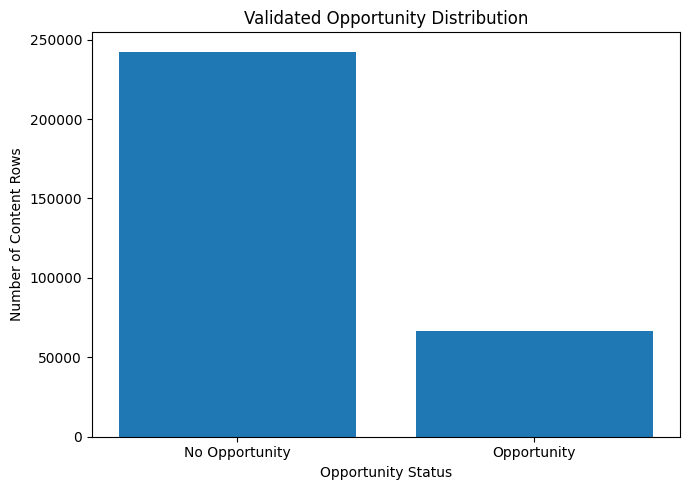

Created:
- work/outputs/week7_metrics.json
- work/figures/week7_opportunity_distribution.png

Metrics:
- total_validated_rows: 309234
- opportunity_rows: 66762
- opportunity_rate: 0.2159
- ranking_method: impressions descending, CTR ascending, average position ascending
- human_review_required: True
- automatic_publishing: False
- automatic_deletion: False


In [40]:
from pathlib import Path
import json
import matplotlib.pyplot as plt

# Create required folders
Path("work/outputs").mkdir(parents=True, exist_ok=True)
Path("work/figures").mkdir(parents=True, exist_ok=True)

# Verified Week 7 results
total_rows = 309234
opportunity_rows = 66762
not_opportunity_rows = total_rows - opportunity_rows

# Metrics artifact
metrics = {
    "total_validated_rows": total_rows,
    "opportunity_rows": opportunity_rows,
    "opportunity_rate": round(opportunity_rows / total_rows, 4),
    "ranking_method": "impressions descending, CTR ascending, average position ascending",
    "human_review_required": True,
    "automatic_publishing": False,
    "automatic_deletion": False
}

metrics_path = Path("work/outputs/week7_metrics.json")

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

# Figure 1
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Opportunity", "Opportunity"],
    [not_opportunity_rows, opportunity_rows]
)

plt.title("Validated Opportunity Distribution")
plt.xlabel("Opportunity Status")
plt.ylabel("Number of Content Rows")
plt.tight_layout()

figure1_path = Path("work/figures/week7_opportunity_distribution.png")
plt.savefig(figure1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Created:")
print("-", metrics_path)
print("-", figure1_path)

print("\nMetrics:")
for key, value in metrics.items():
    print(f"- {key}: {value}")

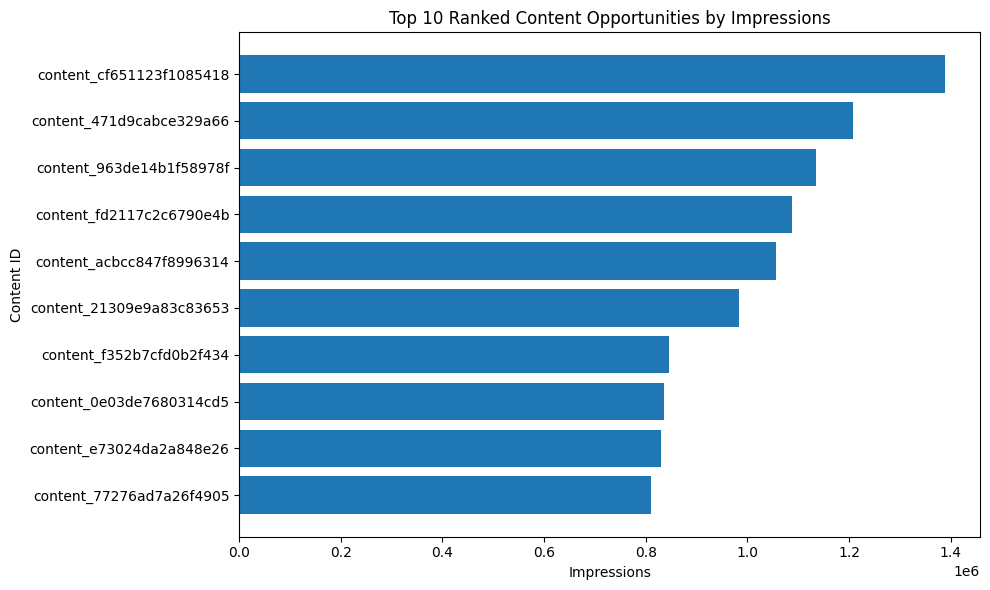

Figure exported to: work/figures/week7_top10_action_queue.png

Top 10 rows:
            content_hash_id  impressions
0  content_cf651123f1085418      1388464
1  content_471d9cabce329a66      1208380
2  content_963de14b1f58978f      1135755
3  content_fd2117c2c6790e4b      1088345
4  content_acbcc847f8996314      1055962
5  content_21309e9a83c83653       983861
6  content_f352b7cfd0b2f434       845725
7  content_0e03de7680314cd5       836178
8  content_e73024da2a848e26       829969
9  content_77276ad7a26f4905       809647


In [41]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Verified Week 7 Top-10 action queue
top10 = pd.DataFrame({
    "content_hash_id": [
        "content_cf651123f1085418",
        "content_471d9cabce329a66",
        "content_963de14b1f58978f",
        "content_fd2117c2c6790e4b",
        "content_acbcc847f8996314",
        "content_21309e9a83c83653",
        "content_f352b7cfd0b2f434",
        "content_0e03de7680314cd5",
        "content_e73024da2a848e26",
        "content_77276ad7a26f4905"
    ],
    "impressions": [
        1388464,
        1208380,
        1135755,
        1088345,
        1055962,
        983861,
        845725,
        836178,
        829969,
        809647
    ]
})

plt.figure(figsize=(10, 6))

plt.barh(
    top10["content_hash_id"],
    top10["impressions"]
)

plt.title("Top 10 Ranked Content Opportunities by Impressions")
plt.xlabel("Impressions")
plt.ylabel("Content ID")
plt.gca().invert_yaxis()
plt.tight_layout()

figure2_path = Path("work/figures/week7_top10_action_queue.png")
plt.savefig(figure2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Figure exported to:", figure2_path)
print("\nTop 10 rows:")
print(top10)

In [42]:
from pathlib import Path

artifacts = [
    "work/outputs/week7_metrics.json",
    "work/figures/week7_opportunity_distribution.png",
    "work/figures/week7_top10_action_queue.png"
]

print("CAPSTONE ARTIFACT CHECK\n")

for artifact in artifacts:
    path = Path(artifact)
    print(f"{artifact}: {'FOUND' if path.exists() else 'MISSING'}")

CAPSTONE ARTIFACT CHECK

work/outputs/week7_metrics.json: FOUND
work/figures/week7_opportunity_distribution.png: FOUND
work/figures/week7_top10_action_queue.png: FOUND


# ML-12: Closing Deliverables

## 5-Minute Demo Outline
### 1. Problem — 1 minute
Explain the CTR/Engagement Opportunity Scoring problem:
identify existing content with high search visibility, relatively low CTR, and good average search position so that it can be prioritized for human review.

### 2. Data & Method — 1 minute
Briefly explain the FlyRank internship warehouse, the client-content aggregation, the rule-based baseline, and the Decision Tree model.

### 3. Results — 1 minute
Show the measured evaluation results and explain that the Decision Tree reproduced the rule-defined opportunity label with perfect measured performance on the evaluated validation splits.

### 4. Ranked Action Queue — 1 minute
Show the opportunity distribution and ranked recommendations. Explain that higher impressions, lower CTR, and better average position are used to prioritize content for review.

### 5. Limitations & Decision — 1 minute
Emphasize that this is decision-support, not a causal claim or guaranteed CTR improvement. Human review is required before any content refresh or other action.

## Social-Post Cut

Completed my Week 8 capstone for the FlyRank AI Machine Learning Engineering Internship.

For this capstone, I worked on **CTR / Engagement Opportunity Scoring** to identify existing content with high search visibility, relatively low CTR, and good average search position.

The workflow covered problem framing, data aggregation, a rule-based baseline, Decision Tree modeling, client-grouped validation, honest claim framing, and a ranked action queue for human review.

One key learning was that strong classification metrics do not automatically mean future business impact. In this case, the model primarily reproduced the existing rule-defined opportunity label, so the output is treated as **decision support rather than a causal or guaranteed improvement claim**.

\#MachineLearning \#DataScience \#FlyRankAI

## Employer-Facing Summary

I developed a CTR / Engagement Opportunity Scoring workflow that identifies and prioritizes existing content with high search visibility, relatively low CTR, and good average search position.

The project combines a rule-based baseline, Decision Tree analysis, client-grouped validation, and a ranked action queue to support practical content-review decisions.

The main takeaway is that the model successfully reproduced the existing rule-defined opportunity label, while the final workflow keeps human review in the loop and avoids unsupported causal or guaranteed-improvement claims.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
